In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import interpolate
from numpy import float64
import time

In [2]:
import sys
import os
import importlib


# Get the parent directory of the current file
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import methods
importlib.reload(methods)
import solvers
importlib.reload(solvers)
import utils
importlib.reload(utils)

e:\anaconda3\envs\Graph_Ginzburg_Landau\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'utils' from 'd:\\PhD at UCLA\\Allen-Cahn and Cahn-Hilliard\\Stabilized_RK_Allen_Cahn_Cahn_Hillard\\SRK\\utils.py'>

In [3]:
#Time and space range
a_x = 0
b_x = 2 * np.pi
a_y = 0
b_y = 2 * np.pi

s = 100

#Initial x grid size and t grid size
Nx = 256
Ny = 256

dx = float64((b_x - a_x) / Nx)
dy = float64((b_y - a_y) / Ny)

T = 1
eps = 0.1           # Choose like this so that eps^2=0.01

dt = T / 4

bc= "Periodic"


print("Initial dt used is " + str(dt))
print("eps used is " + str(eps))

Initial dt used is 0.25
eps used is 0.1


In [4]:
'''
Initial Condition for the Cahn-Hilliard simulation
'''
def initial_condition(mesh_grid):
    X, Y = mesh_grid
    return 0.05 * np.sin(X) * np.sin(Y)

Solving:   0%|                                                              | 0/5 [00:00<?, ?iter/s]

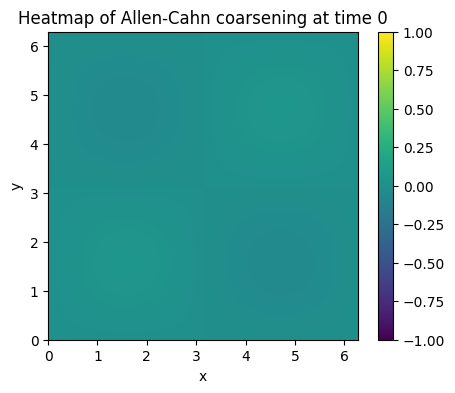

Max value of u_total[-1] is 0.05
Min value of u_total[-1] is -0.05


Solving:  80%|███████████████████████████████████████████▏          | 4/5 [00:01<00:00,  3.32iter/s]

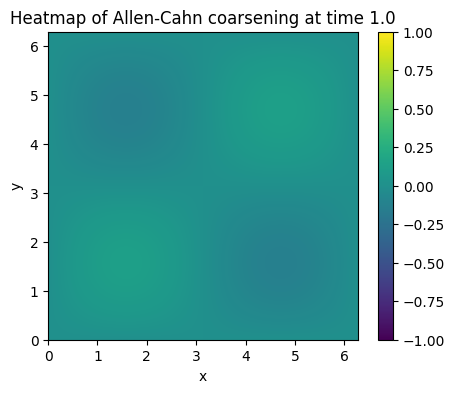

Max value of u_total[-1] is 0.1322120866453929
Min value of u_total[-1] is -0.13221208664539222


Solving: 100%|██████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.02iter/s]


Final t is 1.0


Solving:   0%|                                                              | 0/9 [00:00<?, ?iter/s]

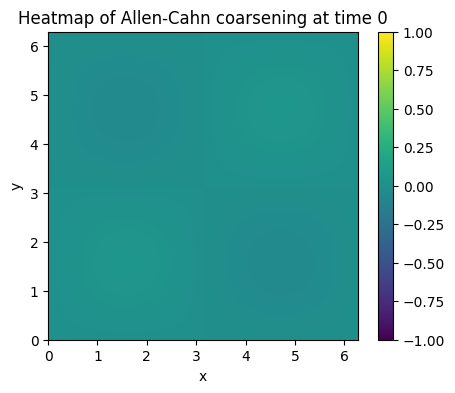

Max value of u_total[-1] is 0.05
Min value of u_total[-1] is -0.05


Solving:  89%|████████████████████████████████████████████████      | 8/9 [00:03<00:00,  2.34iter/s]

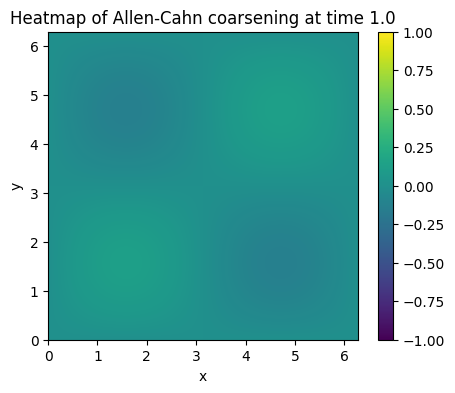

Max value of u_total[-1] is 0.1322120903101228
Min value of u_total[-1] is -0.13221209031012263


Solving: 100%|██████████████████████████████████████████████████████| 9/9 [00:04<00:00,  2.20iter/s]


Final t is 1.0


Solving:   0%|                                                             | 0/17 [00:00<?, ?iter/s]

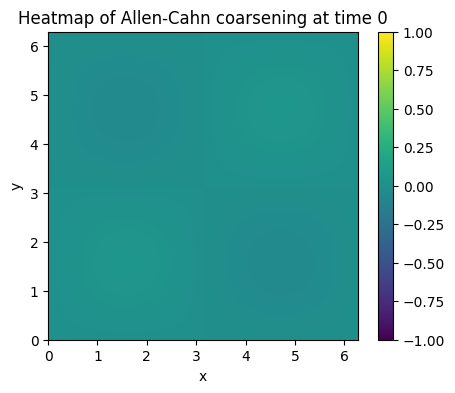

Max value of u_total[-1] is 0.05
Min value of u_total[-1] is -0.05


Solving:  94%|████████████████████████████████████████████████▉   | 16/17 [00:06<00:00,  2.13iter/s]

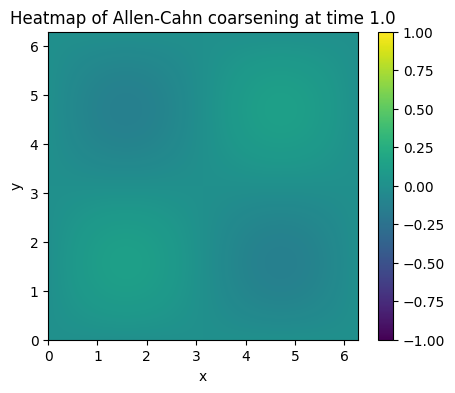

Max value of u_total[-1] is 0.1322120912527359
Min value of u_total[-1] is -0.13221209125273875


Solving: 100%|████████████████████████████████████████████████████| 17/17 [00:06<00:00,  2.50iter/s]


Final t is 1.0


Solving:   0%|                                                             | 0/33 [00:00<?, ?iter/s]

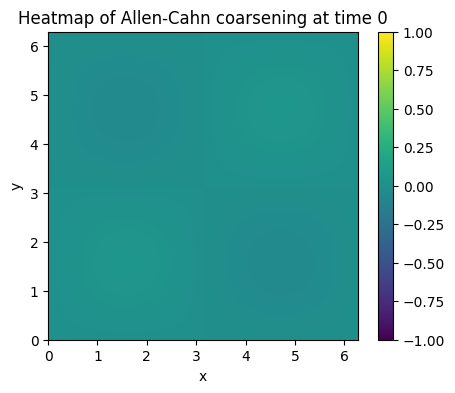

Max value of u_total[-1] is 0.05
Min value of u_total[-1] is -0.05


Solving:  97%|██████████████████████████████████████████████████▍ | 32/33 [00:12<00:00,  2.60iter/s]

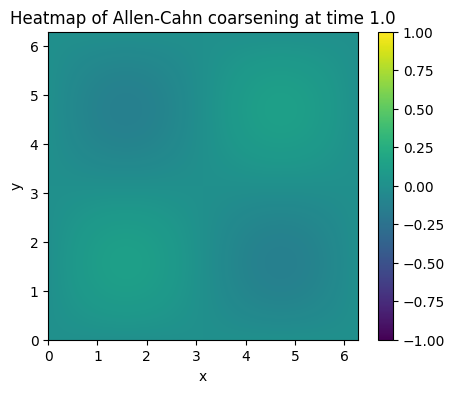

Max value of u_total[-1] is 0.1322120914900352
Min value of u_total[-1] is -0.1322120914900286


Solving: 100%|████████████████████████████████████████████████████| 33/33 [00:12<00:00,  2.56iter/s]


Final t is 1.0


Solving:   0%|                                                             | 0/65 [00:00<?, ?iter/s]

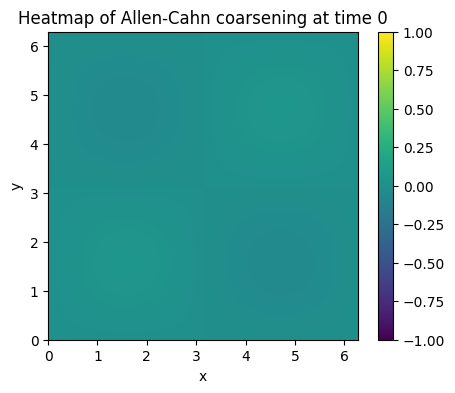

Max value of u_total[-1] is 0.05
Min value of u_total[-1] is -0.05


Solving:  98%|███████████████████████████████████████████████████▏| 64/65 [00:20<00:00,  3.28iter/s]

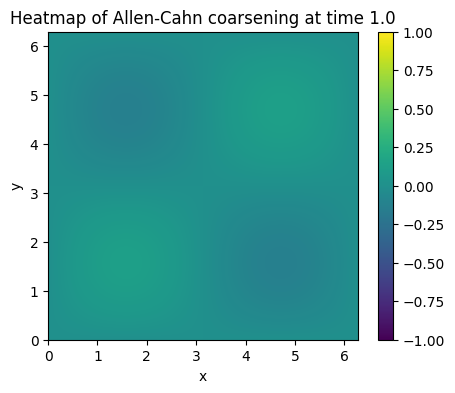

Max value of u_total[-1] is 0.13221209154944757
Min value of u_total[-1] is -0.13221209154944294


Solving: 100%|████████████████████████████████████████████████████| 65/65 [00:20<00:00,  3.14iter/s]


Final t is 1.0


Solving:   0%|                                                            | 0/129 [00:00<?, ?iter/s]

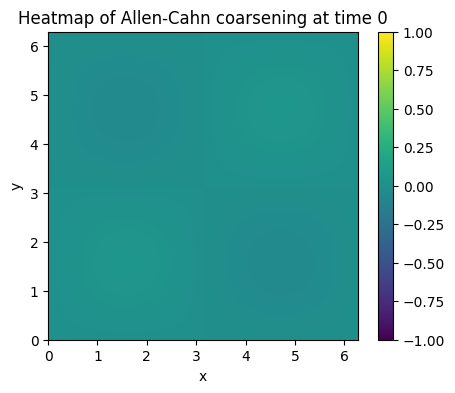

Max value of u_total[-1] is 0.05
Min value of u_total[-1] is -0.05


Solving:  78%|██████████████████████████████████████▊           | 100/129 [00:29<00:09,  3.16iter/s]

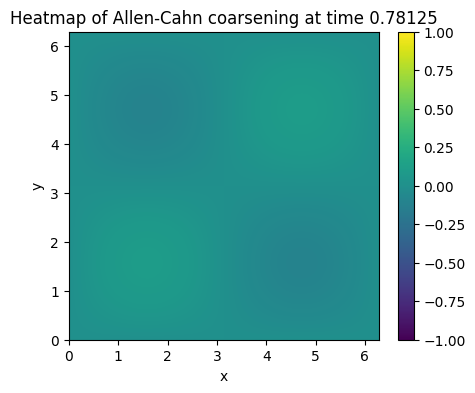

Max value of u_total[-1] is 0.10702906142328375
Min value of u_total[-1] is -0.10702906142328997


Solving:  99%|█████████████████████████████████████████████████▌| 128/129 [00:38<00:00,  3.35iter/s]

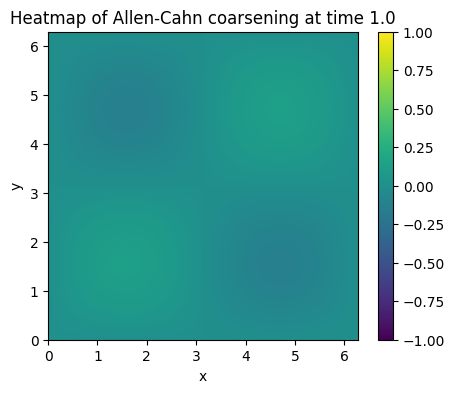

Max value of u_total[-1] is 0.13221209156432984
Min value of u_total[-1] is -0.13221209156432867


Solving: 100%|██████████████████████████████████████████████████| 129/129 [00:38<00:00,  3.31iter/s]

Final t is 1.0


In [ ]:
'''
Test for the order of convergence
'''
test_num = 6

final_simulation = []

for i in range(test_num):
    my_solver = solvers.Allen_Cahn_Solver_2D_Constant_Timestep("RKL2_2D", s, Nx, Ny, dt/2**i, dx, dy, a_x, b_x, a_y, b_y, initial_condition, T, eps, bc=bc, energy_case=3, plot_frequency=100, splitting_order="NLN")
    # my_solver = solvers.Allen_Cahn_Solver_2D_Constant_Timestep("RKG2_2D", s, Nx, Ny, dt/2**i, dx, dy, a_x, b_x, a_y, b_y, initial_condition, T, eps, bc=bc, energy_case=3, plot_frequency=100, splitting_order="NLN")
    my_solver.initialize(display=False)

    my_solver.solve()
    u_total, t_total, energy_total, energy_modified_total, mesh_grid = my_solver.get_results()
    print("Final t is " + str(t_total[-2]))
    final_simulation.append(u_total[-2])

In [13]:
error_list = []
for i in range(test_num-1):
    test_vec = (final_simulation[i] - final_simulation[i+1]).reshape(-1)
    error_list.append(np.linalg.norm(test_vec, ord=2))

order_list = []
for i in range(len(error_list)-1):
    order_list.append(np.log(error_list[i]/error_list[i+1])/np.log(2))

print(error_list)
print(order_list)

[np.float64(1.3119035781230397e-05), np.float64(3.300535606140754e-06), np.float64(8.264288947469979e-07), np.float64(2.0668702223462763e-07), np.float64(5.16764176511294e-08)]
[np.float64(1.990889622060695), np.float64(1.9977375602408212), np.float64(1.9994428910062956), np.float64(1.9998698384792708)]


In [14]:
error_list = []
for i in range(test_num-1):
    test_vec = (final_simulation[i] - final_simulation[i+1]).reshape(-1)
    error_list.append(np.linalg.norm(test_vec, ord=np.inf))

order_list = []
for i in range(len(error_list)-1):
    order_list.append(np.log(error_list[i]/error_list[i+1])/np.log(2))

print(error_list)
print(order_list)

[np.float64(9.263232708667246e-08), np.float64(2.3311002878001474e-08), np.float64(5.83731085690431e-09), np.float64(1.4599175895968486e-09), np.float64(3.6502072198185687e-10)]
[np.float64(1.9905046841436347), np.float64(1.9976352690775774), np.float64(1.999416965554336), np.float64(1.9998366609294185)]
